In [1]:
# Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # Import train_test_split function 
from sklearn.neighbors import KNeighborsClassifier as KNC # Import KNN Classifier 
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier 
from sklearn import metrics #Import scikit-learn metrics module for accuracy calculation 
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Loading data from excel file

In [35]:
data=pd.read_excel("C:/Users/HP/Downloads/Fire detection.xlsx")

In [36]:
data.head(10)

,CO,CO2,Temperature,Smog,Class_label
0,34,1564,206,177,May be Fire
1,13,1951,239,419,May be Fire
2,33,2319,150,16,No Fire
3,30,1149,158,268,Fire
4,4,918,402,4,No Fire
5,16,1703,283,235,May be Fire
6,30,464,439,164,May be Fire
7,34,2401,75,306,May be Fire
8,12,1940,181,162,May be Fire
9,28,2616,255,459,May be Fire


In [69]:
# Checking for missing values in the dataset.

In [70]:
data.isna().sum()

CO             0
CO2            0
Temperature    0
Smog           0
Class_label    0
dtype: int64

In [71]:
# Note: There are no missing values in the dataset

In [72]:
# Checking the shape (rows and columns), info and the basic measures of descriptive statistics from the data.

In [74]:
print('The number of rows of the dataframe is',data.shape[0],'.')

print('The number of columns of the dataframe is',data.shape[1],'.')


The number of rows of the dataframe is 1000 .
The number of columns of the dataframe is 5 .


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
CO             1000 non-null int64
CO2            1000 non-null int64
Temperature    1000 non-null int64
Smog           1000 non-null int64
Class_label    1000 non-null object
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


In [77]:
data.describe()

,CO,CO2,Temperature,Smog
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,38.629000,1881.806000,292.904000,292.437000
std,16.113566,687.934421,129.420247,157.607081
min,1.000000,358.000000,3.000000,0.000000
25%,28.000000,1454.250000,214.000000,170.000000
50%,38.000000,1984.000000,287.000000,274.000000
75%,51.000000,2460.250000,382.000000,417.250000
max,75.000000,3136.000000,541.000000,653.000000


In [78]:
# categorical variable

In [80]:
#Since the variable is categorical, you can use value_counts function
pd.value_counts(data['Class_label'])

May be Fire    618
No Fire        301
Fire            81
Name: Class_label, dtype: int64

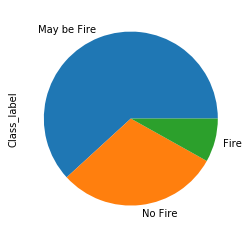

In [81]:
pd.value_counts(data['Class_label']).plot(kind="pie")
plt.show()

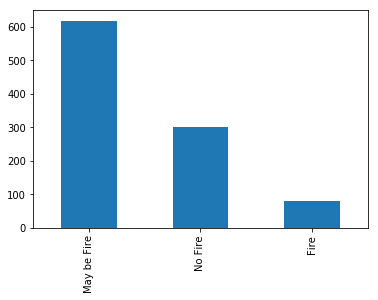

In [82]:
pd.value_counts(data['Class_label']).plot(kind="bar")
plt.show()

In [83]:
# Check for Outliers

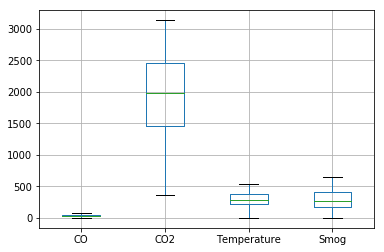

In [84]:
data.boxplot()

In [85]:
# There are no outliers present in the data

In [195]:
#filter rows of original data
filtered_label0 = data[data['Class_label']== 'May be Fire']


In [86]:
#to split train and test data

In [109]:
train, test=train_test_split(data, test_size=0.3, random_state=2)

# KNN

In [110]:
#model building for k-3

neigh=KNC(n_neighbors=3)

neigh.fit(train.iloc[:,0:4],train.iloc[:,4])

train_predict=neigh.predict(train.iloc[:,0:4])

pd.crosstab(train_predict,train.iloc[:,4])

Class_label,Fire,May be Fire,No Fire
row_0,,,
Fire,52,1,1
May be Fire,3,418,5
No Fire,1,12,207


In [111]:
train_acc=np.mean(neigh.predict(train.iloc[:,0:4])==train.iloc[:,4])

train_acc

0.9671428571428572

In [112]:
test_predict=neigh.predict(test.iloc[:,0:4])

print(test_predict)

['May be Fire' 'No Fire' 'May be Fire' 'May be Fire' 'No Fire' 'No Fire'
 'May be Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'No Fire'
 'May be Fire' 'May be Fire' 'Fire' 'No Fire' 'May be Fire' 'May be Fire'
 'Fire' 'May be Fire' 'No Fire' 'May be Fire' 'No Fire' 'May be Fire'
 'No Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'No Fire' 'May be Fire'
 'No Fire' 'May be Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'No Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'No Fire' 'May be Fire' 'Fire' 'No Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'No Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'No Fire'
 'May be Fire' 'No Fire' 'May be Fire' 'Fire' 'No Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'Fire' 'Fire' 'No Fire'
 'No Fir

In [113]:
test_acc=np.mean(neigh.predict(test.iloc[:,0:4])==test.iloc[:,4])

test_acc

0.8933333333333333

In [114]:
pd.crosstab(test_predict,test.iloc[:,4])

Class_label,Fire,May be Fire,No Fire
row_0,,,
Fire,21,3,2
May be Fire,1,171,10
No Fire,3,13,76


In [115]:
# Identifying best K value

In [116]:
neighbors = np.arange(1, 9)

train_accuracy = np.empty(len(neighbors))

test_accuracy = np.empty(len(neighbors))

for i, k in enumerate(neighbors):
    
    knn = KNC(n_neighbors=k)
    
    knn.fit(train.iloc[:,0:4],train.iloc[:,4])
    
    # Compute training and test data accuracy
    
    train_accuracy[i]= knn.score(train.iloc[:,0:4],train.iloc[:,4])
    
    test_accuracy[i] = knn.score(test.iloc[:,0:4],test.iloc[:,4])


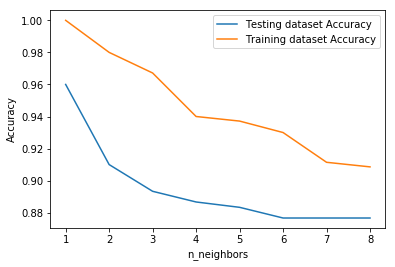

In [117]:
# Generate plot

plt.plot (neighbors, test_accuracy, label = "Testing dataset Accuracy")

plt.plot(neighbors, train_accuracy, label = "Training dataset Accuracy")

plt.legend ()

plt.xlabel("n_neighbors")

plt.ylabel ("Accuracy")

plt.show()

In [118]:
 #model building for k-1

neigh=KNC(n_neighbors=1)

neigh.fit(train.iloc[:,0:4],train.iloc[:,4])

train_predict=neigh.predict(train.iloc[:,0:4])

pd.crosstab(train_predict,train.iloc[:,4])

Class_label,Fire,May be Fire,No Fire
row_0,,,
Fire,56,0,0
May be Fire,0,431,0
No Fire,0,0,213


In [119]:
train_acc=np.mean(neigh.predict(train.iloc[:,0:4])==train.iloc[:,4])

train_acc

1.0

In [120]:
test_predict=neigh.predict(test.iloc[:,0:4])

print(test_predict)

['May be Fire' 'No Fire' 'No Fire' 'May be Fire' 'No Fire' 'No Fire'
 'May be Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'No Fire'
 'May be Fire' 'Fire' 'No Fire' 'No Fire' 'May be Fire' 'May be Fire'
 'Fire' 'May be Fire' 'No Fire' 'May be Fire' 'No Fire' 'May be Fire'
 'No Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'No Fire' 'May be Fire'
 'No Fire' 'May be Fire' 'Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'No Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'No Fire' 'No Fire' 'May be Fire' 'No Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'No Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'No Fire' 'May be Fire' 'No Fire' 'May be Fire' 'May be Fire' 'No Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire'
 'May be Fire' 'May be Fire' 'May be Fire' 'May be Fire' 'Fire' 'Fire'
 'No Fire

In [121]:
test_acc=np.mean(neigh.predict(test.iloc[:,0:4])==test.iloc[:,4])

test_acc

0.96

In [122]:
pd.crosstab(test_predict,test.iloc[:,4])

Class_label,Fire,May be Fire,No Fire
row_0,,,
Fire,23,0,0
May be Fire,0,184,7
No Fire,2,3,81


In [123]:
print ("KNN model with K=1")

print("\n")

print(confusion_matrix(test.iloc[:,4],test_predict))

print("\n")

print(classification_report (test.iloc[:,4],test_predict))

print("\n")

print("accuracy - ",test_acc)

KNN model with K=1


[[ 23   0   2]
 [  0 184   3]
 [  0   7  81]]


              precision    recall  f1-score   support

        Fire       1.00      0.92      0.96        25
 May be Fire       0.96      0.98      0.97       187
     No Fire       0.94      0.92      0.93        88

    accuracy                           0.96       300
   macro avg       0.97      0.94      0.95       300
weighted avg       0.96      0.96      0.96       300



accuracy -  0.96


# Decision Tree

In [178]:
# Create Decision Tree classifer object

clf = DecisionTreeClassifier()

# Train Decision Tree CLassifer

clf = clf.fit(train.iloc[:,0:4],train.iloc[:,4])

#Predict the response for train dataset

train_pred = clf.predict(train.iloc[:,0:4])

In [179]:
# Model Accuracy, how often is the classifier correct?

print ("Accuracy: ",metrics.accuracy_score(train.iloc[:,4], train_pred))

Accuracy:  1.0


In [180]:
pd.crosstab(train_pred,train.iloc[: ,4])

Class_label,Fire,May be Fire,No Fire
row_0,,,
Fire,56,0,0
May be Fire,0,431,0
No Fire,0,0,213


In [181]:
#Predict the response for train dataset

test_pred = clf.predict(test.iloc[:,0:4])

In [182]:
# Model Accuracy, how often is the classifier correct?

print("Accuracy:",metrics.accuracy_score(test.iloc[:,4], test_pred))

Accuracy: 0.93


In [183]:
pd.crosstab(test_pred,test.iloc[:,4])

Class_label,Fire,May be Fire,No Fire
row_0,,,
Fire,22,2,0
May be Fire,1,177,8
No Fire,2,8,80


In [184]:
print ("Decision Tree")

print ("\n")

print(confusion_matrix(test.iloc[:,4],test_pred))

print ("\n")

print (classification_report(test.iloc[:,4],test_pred))

print("\n")

print("Accuracy:",metrics.accuracy_score(test.iloc[:,4], test_pred))

Decision Tree


[[ 22   1   2]
 [  2 177   8]
 [  0   8  80]]


              precision    recall  f1-score   support

        Fire       0.92      0.88      0.90        25
 May be Fire       0.95      0.95      0.95       187
     No Fire       0.89      0.91      0.90        88

    accuracy                           0.93       300
   macro avg       0.92      0.91      0.92       300
weighted avg       0.93      0.93      0.93       300



Accuracy: 0.93
